In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定中文字體，解決中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 設定字體
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題


In [3]:
# 1. 建立模擬財報數據 (包含 "今年 CY" 和 "去年 LY")
# 這些數據通常要從資料庫撈，這裡我們手動建立
data = {
    'Company': ['台積電', '聯發科', '宏達電', '轉機股', '地雷科'],
    
    # --- 獲利能力相關 (Profitability) ---
    'NetIncome_CY': [1000, 500, -20, 100, 50],    # 今年淨利
    'NetIncome_LY': [900,  480, -50, -100, 60],   # 去年淨利 (看有沒有進步)
    'CFO_CY':       [1200, 600, -10, 150, -20],   # 今年營業現金流 (這很重要！要是正的)
    'Assets_CY':    [5000, 2000, 800, 1000, 500], # 總資產
    'Assets_LY':    [4500, 1900, 850, 1000, 500], # 去年總資產 (用來算 ROA)
    
    # --- 償債與結構 (Leverage, Liquidity, Source of Funds) ---
    'LongTermDebt_CY': [500, 200, 300, 400, 450], # 長期負債
    'LongTermDebt_LY': [550, 200, 250, 500, 300], # 去年負債 (負債減少才得分)
    'CurrentRatio_CY': [2.5, 2.0, 1.1, 1.5, 0.8], # 流動比率
    'CurrentRatio_LY': [2.2, 1.9, 1.2, 1.2, 0.9], # 去年流動比率 (流動性變好才得分)
    'Shares_CY':       [100, 50, 80, 100, 120],   # 流通股數
    'Shares_LY':       [100, 50, 80, 100, 100],   # 去年股數 (沒有增資/印股票才得分)
    
    # --- 營運效率 (Operating Efficiency) ---
    'GrossMargin_CY':  [0.55, 0.48, 0.30, 0.25, 0.10], # 毛利率
    'GrossMargin_LY':  [0.53, 0.48, 0.35, 0.15, 0.12], # 去年毛利率
    'AssetTurnover_CY':[0.8, 0.7, 0.5, 0.9, 0.4],      # 資產週轉率 (營收/資產)
    'AssetTurnover_LY':[0.7, 0.7, 0.6, 0.6, 0.5],      # 去年週轉率
}

df = pd.DataFrame(data)

In [4]:
# --- 2. 計算 F-Score 的 9 大指標 ---
# 先算出 ROA (資產報酬率)
df['ROA_CY'] = df['NetIncome_CY'] / df['Assets_CY']
df['ROA_LY'] = df['NetIncome_LY'] / df['Assets_LY']

# A. 獲利能力 (Profitability) - 4分
# 1. ROA > 0 (今年有賺錢嗎?)
df['F1_ROA'] = np.where(df['ROA_CY'] > 0, 1, 0)
# 2. CFO > 0 (現金流是正的嗎? 比淨利更難作假)
df['F2_CFO'] = np.where(df['CFO_CY'] > 0, 1, 0)
# 3. ROA 成長 (今年 ROA 比去年好嗎?)
df['F3_ROA_Chg'] = np.where(df['ROA_CY'] > df['ROA_LY'], 1, 0)
# 4. 盈餘品質 (現金流 > 淨利? 代表不是靠做帳賺錢的)
df['F4_Quality'] = np.where(df['CFO_CY'] > df['NetIncome_CY'], 1, 0)

# B. 償債與結構 (Leverage & Source of Funds) - 3分
# 5. 負債比率下降 (長債今年 <= 去年?)
df['F5_Leverage'] = np.where(df['LongTermDebt_CY'] <= df['LongTermDebt_LY'], 1, 0)
# 6. 流動比率上升 (流動性變好?)
df['F6_Liquidity'] = np.where(df['CurrentRatio_CY'] > df['CurrentRatio_LY'], 1, 0)
# 7. 未增資 (股數今年 <= 去年? 代表沒有印股票跟股東要錢)
df['F7_NoDilution'] = np.where(df['Shares_CY'] <= df['Shares_LY'], 1, 0)

# C. 營運效率 (Operating Efficiency) - 2分
# 8. 毛利率提升 (產品更有競爭力?)
df['F8_Margin'] = np.where(df['GrossMargin_CY'] > df['GrossMargin_LY'], 1, 0)
# 9. 資產週轉率提升 (資產利用效率變好?)
df['F9_Turnover'] = np.where(df['AssetTurnover_CY'] > df['AssetTurnover_LY'], 1, 0)

In [5]:
# --- 3. 總結算 ---
# 把 F1 到 F9 全部加起來
score_cols = [col for col in df.columns if col.startswith('F')]
df['Total_F_Score'] = df[score_cols].sum(axis=1)

# 顯示結果 (只看分數)
result = df[['Company', 'Total_F_Score'] + score_cols]
print(result.sort_values(by='Total_F_Score', ascending=False))

  Company  Total_F_Score  F1_ROA  F2_CFO  F3_ROA_Chg  F4_Quality  F5_Leverage  \
3     轉機股              9       1       1           1           1            1   
0     台積電              8       1       1           0           1            1   
1     聯發科              6       1       1           0           1            1   
2     宏達電              3       0       0           1           1            0   
4     地雷科              1       1       0           0           0            0   

   F6_Liquidity  F7_NoDilution  F8_Margin  F9_Turnover  
3             1              1          1            1  
0             1              1          1            1  
1             1              1          0            0  
2             0              1          0            0  
4             0              0          0            0  


C:\Users\170134\AppData\Local\Temp\20\ipykernel_33712\2996591784.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_F_Score', y='Company', data=df, palette=colors)


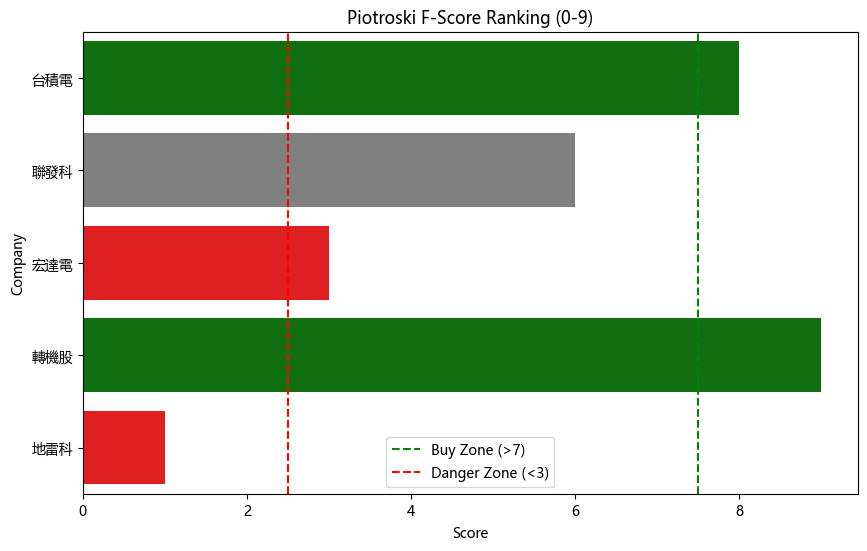

In [6]:
# --- 4. 畫圖呈現 ---
plt.figure(figsize=(10, 6))
colors = ['red' if x < 4 else 'green' if x > 7 else 'gray' for x in df['Total_F_Score']]
sns.barplot(x='Total_F_Score', y='Company', data=df, palette=colors)
plt.title('Piotroski F-Score Ranking (0-9)')
plt.xlabel('Score')
plt.axvline(7.5, color='green', linestyle='--', label='Buy Zone (>7)')
plt.axvline(2.5, color='red', linestyle='--', label='Danger Zone (<3)')
plt.legend()
# plt.savefig('f_score_ranking.png')
plt.show()